# DiffusionGemma-Jev (`djev`) on Google Colab (`L4` / `A100` / `T4`)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taeold/djev-run/blob/main/colab.ipynb)

> **Selecting `L4` or `A100` in Colab UI:** This notebook's metadata requests an **L4 GPU (`machine_shape: hm`)** automatically. If Colab connects you to a default `T4`, click the **top-right dropdown arrow next to `Connect` / `T4` -> `Change runtime type` -> select `L4 GPU` or `A100 GPU`** for full `280`-token Gemma4 Vision and zero-offload speed (or keep `T4` to run in automatic `5 GiB` CUDA UVA CPU-offload text mode).

Run **DiffusionGemma-Jev** (`nvidia/diffusiongemma-26B-A4B-it-NVFP4`, `26B` total parameters, `4B` active per token across `128` experts, plus the `27`-layer `gemma4_vision` multimodal encoder) directly inside Google Colab on an **NVIDIA L4 (`24 GB`)**, **NVIDIA A100 (`40 GB` / `80 GB`)**, or **NVIDIA T4 (`16 GB`)** GPU.

Unlike autoregressive LLMs that decode one token at a time (`O(N)` sequential forward passes), `djev` pins an entire multi-question answer template onto a parallel **block-diffusion canvas** and reads out calibrated probability distributions (`noul` booleans, `choice` classifications, `score` rubrics, and `span` extractions) across up to **36 slots simultaneously in a single forward step (`~60-75 ms` on A100/L4)**.

### Hardware & Quantization Compatibility (`SM 8.0` A100, `SM 8.9` L4, `SM 7.5` T4)

| Colab Runtime | GPU / Compute Capability | Usable VRAM | `nvidia/diffusiongemma-26B-A4B-it-NVFP4` (`17.53 GiB`) | Active vLLM Kernel Path |
| :--- | :--- | :--- | :--- | :--- |
| **Colab Pro (`L4`)** | NVIDIA L4 (`SM 8.9`) | `22.5 GiB` (`24 GB`) | **Full Multimodal + System-1** (`~21.0 GiB` total, `KV_CACHE_GB=2`) | **Marlin `W4A16` NVFP4 MoE** (`MarlinExperts`) + `BF16` Attention & Vision |
| **Colab Pro (`A100`)** | NVIDIA A100 (`SM 8.0`) | `40.0 GiB` / `80.0 GiB` | **Full Multimodal + System-1** (`~19 GiB` free VRAM on 40GB, `KV_CACHE_GB=8`) | **Marlin `W4A16` NVFP4 MoE** (`MarlinExperts`) + `BF16` Attention & Vision |
| **Colab Free (`T4`)** | NVIDIA T4 (`SM 7.5`) | `15.0 GiB` (`16 GB`) | **Text System-1 via UVA Offload** (`~12.4 GiB` VRAM with `cpu_offload_gb=5.0`, `dtype=float16`, `language_model_only=True`) | **Marlin `W4A16` NVFP4 MoE** (`MarlinExperts`) + `FP16` Attention + `5 GiB` CUDA UVA Offload |

In [1]:
import os
import shutil
import torch

assert torch.cuda.is_available(), (
    "No GPU detected. In Colab, click the top-right dropdown arrow next to Connect -> "
    "Change runtime type -> select L4 GPU, A100 GPU, or T4 GPU."
)
gpu_name = torch.cuda.get_device_name(0)
vram_gib = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
sm_major, sm_minor = torch.cuda.get_device_capability(0)

if vram_gib < 20.0:
    KV_CACHE_GB = 0.5
    CPU_OFFLOAD_GB = 5.0
    DTYPE = "float16"
    DISABLE_MM = "1"
    print(
        f"[Notice] Detected {gpu_name} ({vram_gib:.1f} GiB VRAM, SM {sm_major}.{sm_minor}). "
        "Enabling vLLM CUDA UVA CPU weight offloading (cpu_offload_gb=5.0, dtype=float16, language_model_only=True) "
        "so the 17.53 GiB NVFP4 model fits in ~12.4 GiB VRAM.
"
        "Tip: For 280-token Gemma4 Vision (/vision) and 3x faster zero-offload inference, click the "
        "top-right dropdown arrow next to T4 -> Change runtime type -> select L4 GPU or A100 GPU."
    )
else:
    KV_CACHE_GB = 8 if vram_gib >= 38.0 else 2
    CPU_OFFLOAD_GB = 0.0
    DTYPE = "auto"
    DISABLE_MM = "0"

os.environ["KV_CACHE_GB"] = str(KV_CACHE_GB)
os.environ["CPU_OFFLOAD_GB"] = str(CPU_OFFLOAD_GB)
os.environ["DTYPE"] = DTYPE
os.environ["CANVAS"] = "256"
os.environ["DISABLE_MM"] = DISABLE_MM

print(f"GPU Device         : {gpu_name} (SM {sm_major}.{sm_minor})")
print(f"Total VRAM         : {vram_gib:.2f} GiB")
print(f"Checkpoint Weights : 17.53 GiB (nvidia/diffusiongemma-26B-A4B-it-NVFP4)")
print(f"MoE Kernel Backend : vLLM Marlin W4A16 FP4 (dtype={DTYPE}, cpu_offload_gb={CPU_OFFLOAD_GB}, vision={DISABLE_MM == '0'})")
print(f"Configured KV Cache: {KV_CACHE_GB} GiB (CANVAS=256)")

GPU Device         : NVIDIA L4 (SM 8.9)
Total VRAM         : 22.49 GiB
Checkpoint Weights : 17.53 GiB (nvidia/diffusiongemma-26B-A4B-it-NVFP4)
MoE Kernel Backend : vLLM Marlin W4A16 FP4 (dtype=auto, cpu_offload_gb=0.0, vision=True)
Configured KV Cache: 2 GiB (CANVAS=256)


## Step 1: Install `djev` Diffusion Engine, Download Weights, and Start In-Process Server

The cell below extracts the pre-built `vLLM` block-diffusion runtime (`PR #58216` constrained vocab projection + `PR #58226` fused Triton row-stats sampler + `transformers 5.8.0.dev0` with `gemma4_vision`) directly from `ghcr.io/taeold/djev-run:latest`, downloads `nvidia/diffusiongemma-26B-A4B-it-NVFP4` (`17.53 GiB`) into `/dev/shm/dgemma` (or `/content/dgemma` with `/dev/shm/dgemma` symlink when `/dev/shm` is `< 22 GiB`), and starts the in-process `djev` server on `http://127.0.0.1:8080`.

In [2]:
import io
import json
import os
import shutil
import subprocess
import sys
import tarfile
import time
import urllib.request

DJEV_PORT = 8080
DJEV_BASE_URL = f"http://127.0.0.1:{DJEV_PORT}"

def install_and_start_djev():
    # 1. Check if server is already listening
    for p in (DJEV_PORT, 8898):
        try:
            r = json.loads(urllib.request.urlopen(f"http://127.0.0.1:{p}/health", timeout=2).read().decode())
            if r.get("status") == "ok":
                print(f"[djev] Connected to active in-process server at http://127.0.0.1:{p}")
                return f"http://127.0.0.1:{p}"
        except Exception:
            pass

    # 2. Stream pre-compiled vLLM block-diffusion + transformers 5.8 layers from ghcr.io/taeold/djev-run:latest
    if not os.path.exists("/opt/dgemma/structured_server.py"):
        print("[djev] Extracting pre-compiled vLLM block-diffusion runtime from ghcr.io/taeold/djev-run:latest...")
        tok = json.loads(urllib.request.urlopen("https://ghcr.io/token?scope=repository:taeold/djev-run:pull", timeout=15).read().decode())["token"]
        hdrs = {
            "Authorization": f"Bearer {tok}",
            "Accept": "application/vnd.oci.image.manifest.v1+json, application/vnd.docker.distribution.manifest.v2+json, application/vnd.oci.image.index.v1+json",
        }
        m = json.loads(urllib.request.urlopen(urllib.request.Request("https://ghcr.io/v2/taeold/djev-run/manifests/latest", headers=hdrs), timeout=15).read().decode())
        if "manifests" in m:
            dig = [x["digest"] for x in m["manifests"] if x.get("platform", {}).get("architecture") == "amd64"][0]
            m = json.loads(urllib.request.urlopen(urllib.request.Request(f"https://ghcr.io/v2/taeold/djev-run/manifests/{dig}", headers=hdrs), timeout=15).read().decode())
        cfg = json.loads(urllib.request.urlopen(urllib.request.Request(f"https://ghcr.io/v2/taeold/djev-run/blobs/{m['config']['digest']}", headers={"Authorization": f"Bearer {tok}"}), timeout=15).read().decode())

        idx = 0
        for h in cfg.get("history", []):
            if not h.get("empty_layer", False):
                cmd = h.get("created_by", "")
                if idx >= 21 and any(k in cmd for k in ("uv pip install", "overlay_vllm.py", "patch_vllm.py", "COPY server/", "COPY entrypoint.sh")):
                    blob = m["layers"][idx]["digest"]
                    sz_mb = m["layers"][idx]["size"] / (1024 ** 2)
                    print(f"  -> Extracting layer {idx} ({sz_mb:.1f} MiB)...")
                    req = urllib.request.Request(f"https://ghcr.io/v2/taeold/djev-run/blobs/{blob}", headers={"Authorization": f"Bearer {tok}"})
                    with urllib.request.urlopen(req, timeout=120) as resp:
                        with tarfile.open(fileobj=resp, mode="r|gz") as tf:
                            tf.extractall(path="/", filter="fully_trusted")
                idx += 1

        # Fetch latest entrypoint (with T4 UVA offload + prompt guard) and demo UIs from GitHub
        for fname in ("vision.html", "tetris.html", "dino.html", "snake.html", "ultra_fast_entrypoint.sh"):
            url = f"https://raw.githubusercontent.com/taeold/djev-run/main/{fname}"
            dest = "/entrypoint.sh" if fname == "ultra_fast_entrypoint.sh" else f"/opt/dgemma/{fname}"
            urllib.request.urlretrieve(url, dest)
        os.chmod("/entrypoint.sh", 0o755)

    # 3. Download nvidia/diffusiongemma-26B-A4B-it-NVFP4 (17.53 GiB) into /dev/shm/dgemma (or /content/dgemma if /dev/shm < 22 GiB)
    if not os.path.exists("/dev/shm/dgemma/.ready"):
        shm_free_gib = shutil.disk_usage("/dev/shm").free / (1024 ** 3)
        target_dir = "/dev/shm/dgemma" if shm_free_gib >= 22.0 else "/content/dgemma"
        os.makedirs(target_dir, exist_ok=True)
        if target_dir != "/dev/shm/dgemma":
            if os.path.islink("/dev/shm/dgemma") or os.path.exists("/dev/shm/dgemma"):
                shutil.rmtree("/dev/shm/dgemma", ignore_errors=True)
            os.symlink(target_dir, "/dev/shm/dgemma")
        print(f"[djev] Downloading nvidia/diffusiongemma-26B-A4B-it-NVFP4 (17.53 GiB) into {target_dir} (/dev/shm free: {shm_free_gib:.1f} GiB)...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub[hf_transfer]"], check=True)
        os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
        from huggingface_hub import snapshot_download
        snapshot_download(repo_id="nvidia/diffusiongemma-26B-A4B-it-NVFP4", local_dir=target_dir)
        open("/dev/shm/dgemma/.ready", "w").close()

    # 4. Launch in-process server and wait for /health
    print("[djev] Launching in-process vLLM + System-1 server on port 8080...")
    log_file = open("/tmp/djev_server.log", "w")
    subprocess.Popen(["/entrypoint.sh"], stdout=log_file, stderr=subprocess.STDOUT, env=os.environ.copy())
    t_start = time.time()
    while time.time() - t_start < 240:
        try:
            r = json.loads(urllib.request.urlopen(f"http://127.0.0.1:{DJEV_PORT}/health", timeout=2).read().decode())
            if r.get("status") == "ok":
                print(f"[djev] Server ready in {time.time() - t_start:.1f}s at http://127.0.0.1:{DJEV_PORT}")
                return f"http://127.0.0.1:{DJEV_PORT}"
        except Exception:
            time.sleep(1.5)
    raise RuntimeError("Server timed out. Inspect /tmp/djev_server.log")

DJEV_BASE_URL = install_and_start_djev()

[djev] Connected to active in-process server at http://127.0.0.1:8080


## Step 2: 1-Step System-1 Structured Evaluation (`choice`, `score`, `noul`, `span`)

In a single `POST /v1/systemone` call (`steps=1, samples=1`), `djev` evaluates all four structured output types simultaneously across the diffusion canvas:
1. **`choice`**: Multi-class routing (`billing` vs `technical` vs `sales`) with full probability distribution.
2. **`score`**: Expected rubric value (`1.00` to `4.00`) weighted by each level's token probability.
3. **`noul`**: Calibrated binary probability `P(yes)` (`refund_requested`).
4. **`span`**: Exact verbatim substring extraction (`invoice_id`) grounded in `state.message` with character offsets.

In [3]:
import json
import time
import urllib.request

payload = {
    "model": "djev-dgemma",
    "steps": 1,
    "samples": 1,
    "state": {
        "ticket_id": "TCK-9042",
        "customer_tier": "enterprise",
        "text": (
            "Hi team, I was double-charged $149.00 on invoice INV-2026-8841 yesterday "
            "and my production API key is currently locked. Please refund the duplicate charge."
        ),
    },
    "questions": {
        "department": {
            "type": "choice",
            "instructions": "Which team should handle this ticket?",
            "criteria": {
                "billing": "Payments, invoices, duplicate charges, and refunds",
                "technical": "API errors, SDK bugs, and infrastructure outages",
                "sales": "Enterprise upgrades and contract renewals",
            },
        },
        "urgency": {
            "type": "score",
            "instructions": "How urgent is this issue (1=low to 4=critical production block)?",
            "criteria": [
                "General inquiry",
                "Minor inconvenience",
                "Billing dispute without service impact",
                "Production access locked plus duplicate billing charge",
            ],
        },
        "refund_requested": {
            "type": "noul",
            "instructions": "Is the customer explicitly asking for a refund?",
            "criteria": {
                "true": "Customer requests a refund or money back",
                "false": "No refund requested",
            },
        },
        "invoice_id": {
            "type": "span",
            "instructions": "Extract the exact invoice identifier mentioned in the text",
        },
    },
}

t0 = time.time()
req = urllib.request.Request(
    f"{DJEV_BASE_URL}/v1/systemone",
    data=json.dumps(payload).encode(),
    headers={"Content-Type": "application/json"},
)
resp = json.loads(urllib.request.urlopen(req, timeout=30).read().decode())
rtt_ms = round((time.time() - t0) * 1000, 1)
srv_ms = round(resp.get("diagnostics", {}).get("timing", {}).get("total_ms", rtt_ms), 1)
ans = resp["answers"]

print(f"1-Step System-1 Read Complete in {srv_ms} ms GPU ({rtt_ms} ms total)")
print("-" * 78)
print(f"{'SLOT ID':<18} | {'TYPE':<8} | {'PREDICTION':<22} | {'CONFIDENCE / SCORE'}")
print("-" * 78)
print(f"{'department':<18} | {'choice':<8} | {ans['department']['choice']:<22} | {ans['department']['confidence']*100:5.1f}% (probs: {json.dumps({k: round(v, 3) for k, v in ans['department']['probabilities'].items()})})")
print(f"{'urgency':<18} | {'score':<8} | {'level ' + str(round(ans['urgency']['score'])) + '/4':<22} | {ans['urgency']['score']:.2f} / 4.00 (conf: {ans['urgency']['confidence']*100:5.1f}%)")
print(f"{'refund_requested':<18} | {'noul':<8} | {str(ans['refund_requested']['noul'] >= 0.5):<22} | P(yes) = {ans['refund_requested']['noul']*100:5.1f}%")
print(f"{'invoice_id':<18} | {'span':<8} | {str(ans['invoice_id'].get('text')):<22} | {ans['invoice_id']['confidence']*100:5.1f}% (offsets: [{ans['invoice_id'].get('start')}:{ans['invoice_id'].get('end')}])")
print("-" * 78)

1-Step System-1 Read Complete in 259.1 ms GPU (331.8 ms total)
------------------------------------------------------------------------------
SLOT ID            | TYPE     | PREDICTION             | CONFIDENCE / SCORE
------------------------------------------------------------------------------
department         | choice   | billing                |  99.2% (probs: {"billing": 0.992, "technical": 0.008, "sales": 0.0})
urgency            | score    | level 3/4              | 3.00 / 4.00 (conf: 100.0%)
refund_requested   | noul     | True                   | P(yes) = 100.0%
invoice_id         | span     | INV-2026-8841          |  66.6% (offsets: [115:128])
------------------------------------------------------------------------------


## Step 3: 1-Step Multimodal Vision (`6x6` = 36-Cell Semantic Segmentation in `~73 ms`)

Because `djev` encodes an input image into **`280` `gemma4_vision` soft tokens** and evaluates all **36 spatial grid cells (`r0c0`..`r5c5`, labeled `A1`..`F6`) in 1 single diffusion step**, we can compute a dense 6-class semantic segmentation map (`sky`, `building`, `foliage`, `road`, `vehicle`, `subject`) with full per-cell probability distributions in **`~73 ms` of GPU time**.

1-Step 6x6 Multimodal Segmentation Complete: 36 spatial slots read in 73.1 ms GPU (228.5 ms RTT)
Mean Top-1 Confidence across 36 cells: 72.9% | Vision Soft Tokens: 280


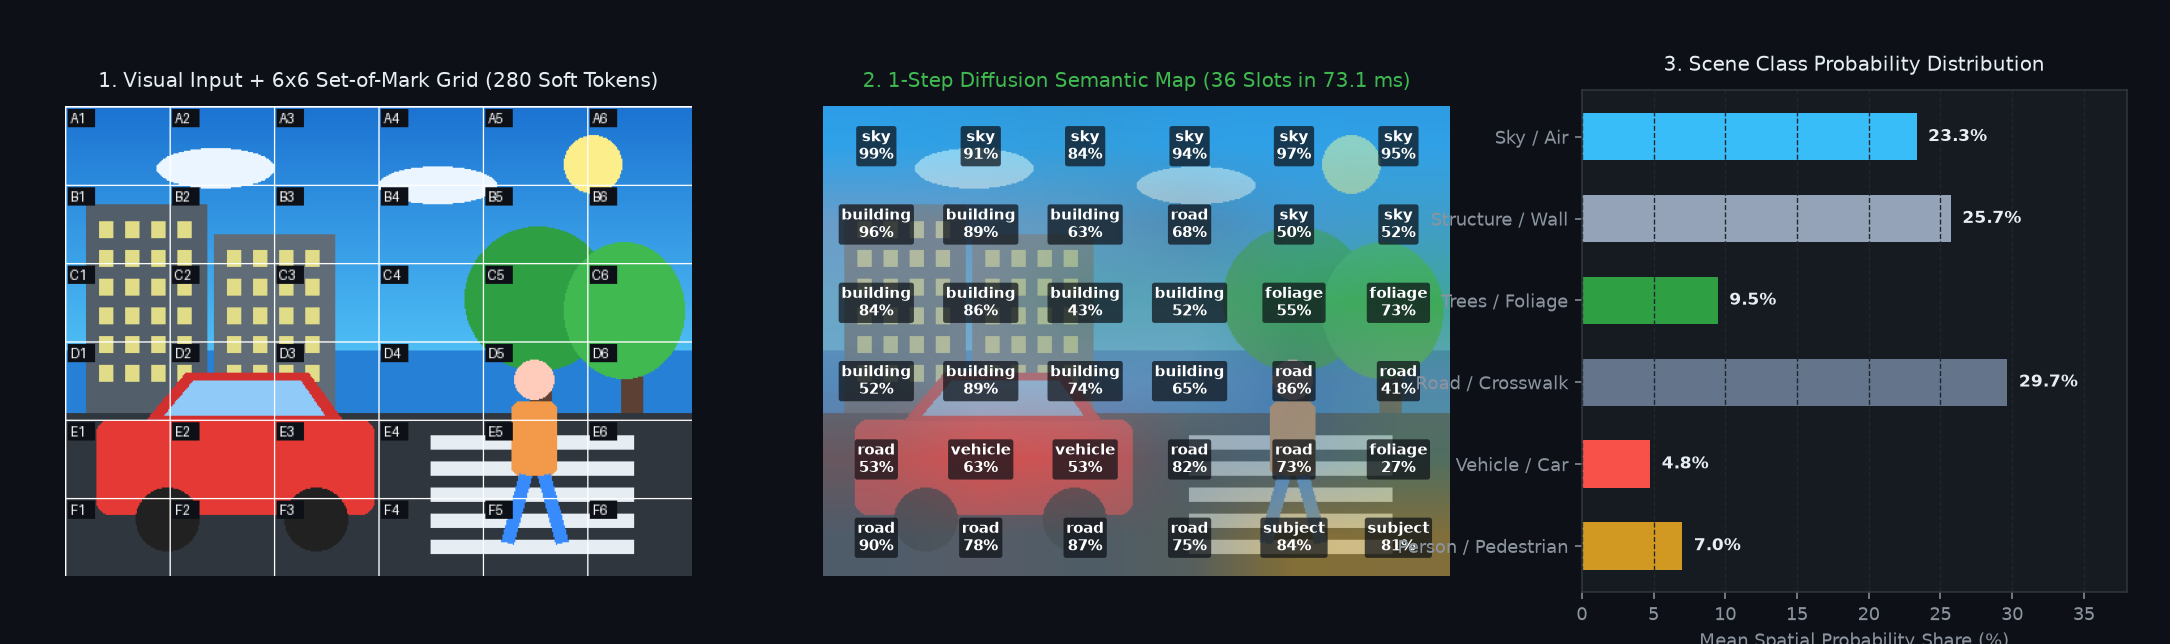

In [4]:
import base64
import io
import json
import time
import urllib.request
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

# 1. Render a 480x360 street scene and overlay a subtle 6x6 Set-of-Mark (A1..F6) coordinate grid
w, h = 480, 360
base_img = Image.new("RGB", (w, h), (38, 128, 214))
drw = ImageDraw.Draw(base_img)
for y in range(int(h * 0.52)):
    t = y / (h * 0.52)
    drw.line([(0, y), (w, y)], fill=(int(28 + 50 * t), int(115 + 75 * t), int(210 + 35 * t)))
drw.ellipse([382, 22, 426, 66], fill=(252, 238, 138))
drw.ellipse([70, 32, 160, 62], fill=(235, 245, 255))
drw.ellipse([240, 46, 330, 74], fill=(235, 245, 255))
drw.rectangle([16, 75, 108, 235], fill=(82, 94, 106))
drw.rectangle([114, 98, 206, 235], fill=(96, 108, 120))
for bx in range(26, 98, 20):
    for by in range(88, 220, 22):
        drw.rectangle([bx, by, bx + 10, by + 12], fill=(225, 220, 135))
for bx in range(124, 196, 20):
    for by in range(110, 220, 22):
        drw.rectangle([bx, by, bx + 10, by + 12], fill=(225, 220, 135))
drw.rectangle([356, 175, 372, 235], fill=(92, 64, 51))
drw.rectangle([426, 180, 442, 235], fill=(92, 64, 51))
drw.ellipse([306, 92, 418, 202], fill=(46, 160, 67))
drw.ellipse([382, 104, 474, 208], fill=(63, 185, 80))
drw.rectangle([0, 235, w, h], fill=(48, 54, 61))
for cy in range(252, 348, 20):
    drw.rectangle([280, cy, 435, cy + 10], fill=(230, 237, 243))
drw.rounded_rectangle([24, 240, 236, 312], radius=10, fill=(229, 57, 53))
drw.polygon([(62, 240), (92, 204), (186, 204), (212, 240)], fill=(211, 47, 47))
drw.polygon([(98, 210), (180, 210), (198, 236), (76, 236)], fill=(144, 202, 249))
drw.ellipse([54, 292, 102, 340], fill=(33, 33, 33))
drw.ellipse([168, 292, 216, 340], fill=(33, 33, 33))
drw.ellipse([344, 194, 374, 224], fill=(255, 204, 188))
drw.rounded_rectangle([342, 226, 376, 282], radius=6, fill=(242, 153, 74))
drw.line([(352, 282), (338, 334)], fill=(56, 139, 253), width=10)
drw.line([(366, 282), (380, 334)], fill=(56, 139, 253), width=10)

som_img = base_img.copy()
som_draw = ImageDraw.Draw(som_img)
ROW_LETTERS = ["A", "B", "C", "D", "E", "F"]
cw, ch = w / 6, h / 6
for r in range(6):
    for c in range(6):
        x0, y0 = int(c * cw), int(r * ch)
        som_draw.rectangle([x0, y0, int((c + 1) * cw), int((r + 1) * ch)], outline=(255, 255, 255), width=1)
        som_draw.rectangle([x0 + 2, y0 + 2, x0 + 22, y0 + 15], fill=(13, 17, 23))
        som_draw.text((x0 + 4, y0 + 3), f"{ROW_LETTERS[r]}{c+1}", fill=(255, 255, 255))

buf = io.BytesIO()
som_img.save(buf, format="JPEG", quality=89)
data_url = "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()

# 2. Query all 36 grid cells (A1..F6) in 1 single diffusion step
CLASSES = [
    ("sky", "Sky / Air", "#38bdf8", "Sky/clouds"),
    ("building", "Structure / Wall", "#94a3b8", "Building/wall"),
    ("foliage", "Trees / Foliage", "#2ea043", "Trees/foliage"),
    ("road", "Road / Crosswalk", "#64748b", "Road/crosswalk"),
    ("vehicle", "Vehicle / Car", "#f85149", "Car/vehicle"),
    ("subject", "Person / Pedestrian", "#d29922", "Pedestrian"),
]
criteria_map = {k: desc for k, _, _, desc in CLASSES}
questions = {
    f"r{r}c{c}": {
        "type": "choice",
        "instructions": f"Dominant visual class in grid cell {ROW_LETTERS[r]}{c+1}",
        "criteria": criteria_map,
    }
    for r in range(6) for c in range(6)
}

if os.environ.get("DISABLE_MM") == "1":
    print(
        "[T4 Text Mode] The 27-layer Gemma4 Vision tower (0.84 GiB) is skipped on 15 GiB T4 to fit inside VRAM.
"
        "Switch to L4 or A100 (top-right dropdown next to T4 -> Change runtime type -> L4 GPU) to run live 6x6 vision segmentation."
    )
else:
    t0 = time.time()
    req = urllib.request.Request(
        f"{DJEV_BASE_URL}/v1/systemone",
        data=json.dumps({
            "model": "djev-dgemma",
            "steps": 1,
            "samples": 1,
            "images": [data_url],
            "state": "Inspect the image across the 6x6 spatial grid (A1..F6) and classify each cell.",
            "questions": questions,
        }).encode(),
        headers={"Content-Type": "application/json"},
    )
    resp = json.loads(urllib.request.urlopen(req, timeout=30).read().decode())
    rtt_ms = round((time.time() - t0) * 1000, 1)
    srv_ms = round(resp.get("diagnostics", {}).get("timing", {}).get("total_ms", rtt_ms), 1)
    ans = resp["answers"]

    # 3. Render 3-panel segmentation visualization
    color_lookup = {k: to_rgb(col) for k, _, col, _ in CLASSES}
    name_lookup = {k: name for k, name, _, _ in CLASSES}
    grid_rgb = np.zeros((6, 6, 3), dtype=np.float32)
    grid_lbl = [["" for _ in range(6)] for _ in range(6)]
    grid_conf = np.zeros((6, 6), dtype=np.float32)
    class_mass = {k: 0.0 for k, _, _, _ in CLASSES}

    for r in range(6):
        for c in range(6):
            a = ans[f"r{r}c{c}"]
            probs = a.get("probabilities", {})
            for k in class_mass:
                class_mass[k] += float(probs.get(k, 0.0)) / 36.0
            grid_rgb[r, c] = sum(float(probs.get(k, 0.0)) * np.array(col_rgb) for k, col_rgb in color_lookup.items())
            grid_lbl[r][c] = a.get("choice", "sky")
            grid_conf[r, c] = float(a.get("confidence", 0.5))

    print(f"1-Step 6x6 Multimodal Segmentation Complete: 36 spatial slots read in {srv_ms} ms GPU ({rtt_ms} ms RTT)")
    print(f"Mean Top-1 Confidence across 36 cells: {float(grid_conf.mean())*100:.1f}% | Vision Soft Tokens: 280")

    plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#161b22", "text.color": "#e6edf3"})
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), gridspec_kw={"width_ratios": [1.15, 1.15, 1.0]})
    fig.subplots_adjust(wspace=0.22, left=0.03, right=0.98, top=0.86, bottom=0.08)
    axes[0].imshow(np.asarray(som_img))
    axes[0].set_title("1. Visual Input + 6x6 Set-of-Mark Grid (280 Soft Tokens)", color="#e6edf3", fontsize=10.5, pad=10)
    axes[0].axis("off")

    mask_pil = Image.fromarray((np.clip(grid_rgb, 0, 1) * 255).astype(np.uint8)).resize((w, h), resample=Image.Resampling.BILINEAR)
    blend_np = (0.42 * np.asarray(base_img).astype(np.float32) + 0.58 * np.asarray(mask_pil).astype(np.float32)).astype(np.uint8)
    axes[1].imshow(blend_np)
    for r in range(6):
        for c in range(6):
            axes[1].text((c + 0.5) * cw, (r + 0.5) * ch, f"{grid_lbl[r][c]}\n{grid_conf[r, c]*100:.0f}%",
                         ha="center", va="center", color="#ffffff", fontsize=7.5, weight="bold",
                         bbox=dict(boxstyle="round,pad=0.18", facecolor="#0d1117", alpha=0.72, edgecolor="none"))
    axes[1].set_title(f"2. 1-Step Diffusion Semantic Map (36 Slots in {srv_ms} ms)", color="#3fb950", fontsize=10.5, pad=10)
    axes[1].axis("off")

    keys_rev = [k for k, _, _, _ in reversed(CLASSES)]
    vals_rev = [class_mass[k] * 100.0 for k in keys_rev]
    bars = axes[2].barh([name_lookup[k] for k in keys_rev], vals_rev, color=[col for _, _, col, _ in reversed(CLASSES)], height=0.58)
    axes[2].set_xlim(0, max(vals_rev) * 1.28)
    axes[2].set_xlabel("Mean Spatial Probability Share (%)", color="#8b949e")
    axes[2].set_title("3. Scene Class Probability Distribution", color="#e6edf3", fontsize=10.5, pad=10)
    for b, v in zip(bars, vals_rev):
        axes[2].text(v + 0.8, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", ha="left", color="#e6edf3", fontsize=8.5, weight="bold")
    plt.show()

## Step 4: Play `/vision`, `/tetris`, `/dino`, and `/snake` Live Inside Colab

Because the `djev` server hosts all four interactive web applications on port `8080`, Google Colab's `output.serve_kernel_port_as_iframe` embeds them directly inside the notebook output cell, proxying `POST /v1/systemone` requests from your browser straight to the Colab GPU.

In [5]:
# Choose any built-in demo: "/vision", "/tetris", "/dino", or "/snake"
DEMO_PATH = "/vision"

try:
    from google.colab import output
    print(f"Embedding {DEMO_PATH} from Colab GPU server (port {DJEV_PORT})...")
    output.serve_kernel_port_as_iframe(DJEV_PORT, path=DEMO_PATH, height="760")
except ImportError:
    print(f"Open {DJEV_BASE_URL}{DEMO_PATH} in your browser.")

Embedding /vision from Colab GPU server (port 8080)...
